# Premium Prediction for Health insurance

# Step-1 : EDA

In [102]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
# loading dataset
df = pd.read_excel("premium_young_data.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712
4,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,15473
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603
17559,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498
17560,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
17561,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564


# EDA + Data Cleaning

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17563 entries, 0 to 17562
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    17563 non-null  int64 
 1   Gender                 17563 non-null  object
 2   Region                 17563 non-null  object
 3   Marital_status         17563 non-null  object
 4   Number Of Dependants   17563 non-null  int64 
 5   BMI_Category           17563 non-null  object
 6   Smoking_Status         17561 non-null  object
 7   Employment_Status      17562 non-null  object
 8   Income_Level           17559 non-null  object
 9   Income_Lakhs           17563 non-null  int64 
 10  Medical History        17563 non-null  object
 11  Insurance_Plan         17563 non-null  object
 12  Annual_Premium_Amount  17563 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 1.7+ MB


In [105]:
df.Income_Level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L', nan], dtype=object)

In [106]:
df.shape

(17563, 13)

In [107]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [108]:
df.columns = df.columns.str.replace(" " , "_")

In [109]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number_Of_Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical_History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [110]:
df.columns = df.columns.str.lower()

In [111]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Handle the Null values

In [112]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [113]:
df.dropna(inplace = True)

In [114]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [115]:
df.shape

(17557, 13)

## Handle duplicate values

In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17557.000000,17557.000000,17557.000000,17557.000000
mean,20.988609,0.715840,22.653585,8161.883237
std,1.998258,0.938388,23.777397,2764.254265
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9575.000000
max,24.000000,3.000000,790.000000,18186.000000


# Numerical columns : Univariate analysis

In [118]:
## Issue-1 : number_of_dependants cannot be in negative

df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
132,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309
759,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095
792,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641
2139,20,Male,Northeast,Unmarried,-3,Underweight,Regular,Freelancer,10L - 25L,20,Diabetes,Silver,9640
2677,20,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Salaried,> 40L,77,No Disease,Silver,9299
3319,23,Female,Southeast,Unmarried,-3,Normal,Regular,Freelancer,25L - 40L,40,No Disease,Bronze,5003
6656,22,Male,Northwest,Unmarried,-3,Normal,Occasional,Self-Employed,<10L,8,No Disease,Gold,13596
8536,18,Female,Southeast,Unmarried,-1,Underweight,No Smoking,Self-Employed,<10L,4,No Disease,Bronze,9366
8849,24,Male,Northeast,Unmarried,-1,Normal,Occasional,Freelancer,<10L,5,No Disease,Silver,9031
12911,22,Male,Northeast,Unmarried,-3,Overweight,No Smoking,Salaried,<10L,2,No Disease,Bronze,7125


In [119]:
df.number_of_dependants.unique()

array([ 0,  2,  1,  3, -3, -1])

In [120]:
df['number_of_dependants'] = df.number_of_dependants.abs()

In [121]:
df.number_of_dependants.unique()

array([0, 2, 1, 3])

In [122]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17557.000000,17557.000000,17557.000000,17557.000000
mean,20.988609,0.720283,22.653585,8161.883237
std,1.998258,0.934982,23.777397,2764.254265
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9575.000000
max,24.000000,3.000000,790.000000,18186.000000


## Handle the Outliers

In [123]:
numeric_columns = df.select_dtypes(include = ['int64', 'float64']).columns
numeric_columns                             

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

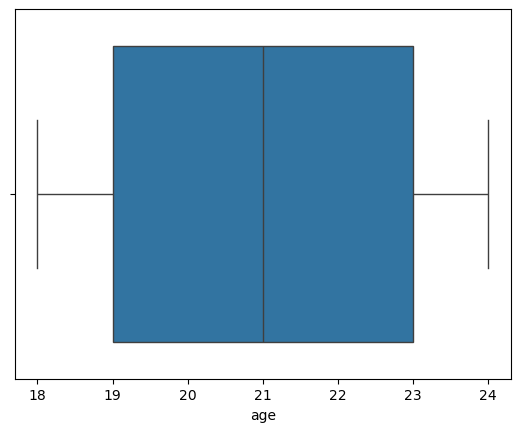

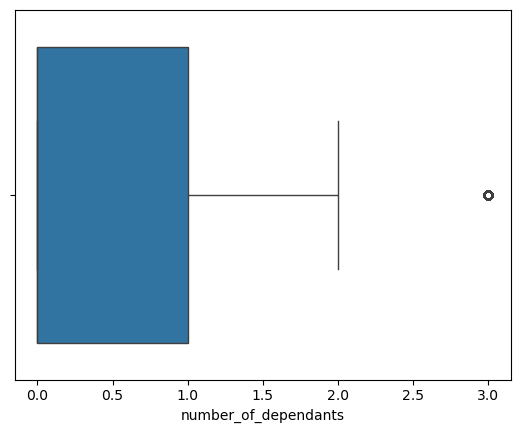

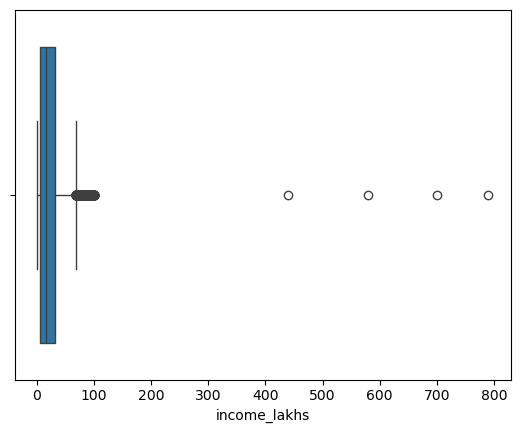

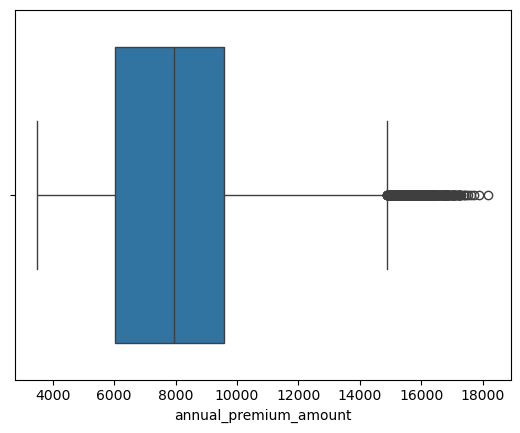

In [124]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

## Handling the Age Outlier

In [125]:
df[df.age > 100]['age'].count()

np.int64(0)

In [126]:
df[df.age > 100]['age'].unique()

array([], dtype=int64)

In [127]:
median = df.age.median()
median

21.0

In [128]:
df.loc[df.age > 100, 'age'] = median

In [129]:
df[df.age > 100]['age'].count()

np.int64(0)

In [130]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17557.000000,17557.000000,17557.000000,17557.000000
mean,20.988609,0.720283,22.653585,8161.883237
std,1.998258,0.934982,23.777397,2764.254265
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9575.000000
max,24.000000,3.000000,790.000000,18186.000000


In [131]:
## Outliers in income_lakhs > 1CR (100)

df[df.income_lakhs > 100]['income_lakhs'].count()

np.int64(4)

In [132]:
# Number of outliers using IQR

Q1, Q3 = df.income_lakhs.quantile([0.25, 0.75])
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

LB, UB

(-31.5, 68.5)

In [133]:
df[df.income_lakhs > UB]['income_lakhs'].count()

np.int64(1155)

In [134]:
df = df[df.income_lakhs <= 100]

In [135]:
df.shape

(17553, 13)

In [136]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,17553.000000,17553.000000,17553.000000,17553.000000
mean,20.988606,0.720447,22.515752,8161.547884
std,1.998457,0.935025,21.867015,2764.266929
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6035.000000
50%,21.000000,0.000000,16.000000,7951.000000
75%,23.000000,1.000000,31.000000,9574.000000
max,24.000000,3.000000,100.000000,18186.000000


# EDA & DC on Caegorical data

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17553 entries, 0 to 17562
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    17553 non-null  int64 
 1   gender                 17553 non-null  object
 2   region                 17553 non-null  object
 3   marital_status         17553 non-null  object
 4   number_of_dependants   17553 non-null  int64 
 5   bmi_category           17553 non-null  object
 6   smoking_status         17553 non-null  object
 7   employment_status      17553 non-null  object
 8   income_level           17553 non-null  object
 9   income_lakhs           17553 non-null  int64 
 10  medical_history        17553 non-null  object
 11  insurance_plan         17553 non-null  object
 12  annual_premium_amount  17553 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 1.9+ MB


In [138]:
categorical_columns = df.select_dtypes(include = ['object']).columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [139]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status  :  ['Regular' 'No Smoking' 'Occasional' 'Not Smoking' 'Does Not Smoke'
 'Smoking=0']
employment_status  :  ['Self-Employed' 'Freelancer' 'Salaried']
income_level  :  ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history  :  ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan  :  ['Silver' 'Bronze' 'Gold']


In [140]:
df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_7912\2744095914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})


In [141]:
df.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

In [142]:
df.shape

(17553, 13)

# Step-2 : Feature Engineering

In [143]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status  :  ['Regular' 'No Smoking' 'Occasional']
employment_status  :  ['Self-Employed' 'Freelancer' 'Salaried']
income_level  :  ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history  :  ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan  :  ['Silver' 'Bronze' 'Gold']


In [144]:
risk_score = {
    'Diabetes' : 6,
    'Heart disease' : 8,
    'High blood pressure' : 6,
    'Thyroid' : 5,
    'No Disease' : 0
}

In [145]:
df1 = df.copy()

In [146]:
df1[['disease1', 'disease2']] = df1['medical_history'].str.split(" & ", expand = True)

In [147]:
df1.disease1 = df1.disease1.map(risk_score)

In [148]:
df1.disease2 = df1.disease2.map(risk_score)

In [149]:
df1.disease1.isnull().sum()

np.int64(0)

In [150]:
df1.disease2.isnull().sum()

np.int64(16674)

In [151]:
df1.disease2 = df1.disease2.fillna(0)

In [152]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,6,0.0
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,0,0.0
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,0,0.0
3,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,0,0.0
4,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,15473,6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,0,0.0
17559,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,6,0.0
17560,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,0,0.0
17561,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,0,0.0


In [153]:
df1['total_risk_score'] = df1['disease1'] + df1['disease2']

In [154]:
df1 = df1.drop(['medical_history', 'disease1', 'disease2'], axis = 1)
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,6.0
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,Silver,11050,0.0
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,Silver,11857,0.0
3,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,5712,0.0
4,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,Gold,15473,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,Gold,11603,0.0
17559,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Gold,14498,6.0
17560,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.0
17561,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.0


In [155]:
# checking sub-categories of each column
categorical_columns = df1.select_dtypes(include = ['object']).columns
categorical_columns

for col in categorical_columns:
    print(col, " : ", df1[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status  :  ['Regular' 'No Smoking' 'Occasional']
employment_status  :  ['Self-Employed' 'Freelancer' 'Salaried']
income_level  :  ['> 40L' '<10L' '10L - 25L' '25L - 40L']
insurance_plan  :  ['Silver' 'Bronze' 'Gold']


### Apply Ordinal encoding to convert insurance_plan & income_level into neumerical

In [156]:
# use ordinal encoding when Order/Ranking matters

In [157]:
from sklearn.preprocessing import OrdinalEncoder

In [158]:
encoder = OrdinalEncoder(categories = [['Bronze','Silver','Gold']])
df1['insurance_plan'] = encoder.fit_transform(df1[['insurance_plan']])

In [159]:
encoder = OrdinalEncoder(categories = [['<10L','10L - 25L','25L - 40L', '> 40L']])
df1['income_level'] = encoder.fit_transform(df1[['income_level']])

In [160]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,3.0,99,1.0,13365,6.0
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,0.0,3,1.0,11050,0.0
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,3.0,97,1.0,11857,0.0
3,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,1.0,14,0.0,5712,0.0
4,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,2.0,30,2.0,15473,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,3.0,91,2.0,11603,0.0
17559,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,3.0,57,2.0,14498,6.0
17560,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,2.0,35,0.0,9111,0.0
17561,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,2.0,32,0.0,8564,0.0


## Apply Label encoder on region and bmi_category

In [161]:
# Order/Ranking don't matter in Label encoding

In [162]:
from sklearn.preprocessing import LabelEncoder

In [163]:
encoder = LabelEncoder()
for col in ['region', 'bmi_category']:
    df1[col] = encoder.fit_transform(df1[col])

In [164]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,18,Male,0,Unmarried,0,2,Regular,Self-Employed,3.0,99,1.0,13365,6.0
1,22,Female,1,Unmarried,0,3,No Smoking,Freelancer,0.0,3,1.0,11050,0.0
2,21,Female,2,Unmarried,0,0,Regular,Salaried,3.0,97,1.0,11857,0.0
3,20,Male,2,Unmarried,2,2,No Smoking,Freelancer,1.0,14,0.0,5712,0.0
4,22,Female,3,Unmarried,0,3,Regular,Freelancer,2.0,30,2.0,15473,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,Female,2,Unmarried,0,3,No Smoking,Freelancer,3.0,91,2.0,11603,0.0
17559,23,Female,1,Unmarried,0,1,Occasional,Freelancer,3.0,57,2.0,14498,6.0
17560,24,Female,1,Unmarried,0,3,No Smoking,Self-Employed,2.0,35,0.0,9111,0.0
17561,21,Male,1,Unmarried,0,0,Regular,Freelancer,2.0,32,0.0,8564,0.0


### convert into numeric using one-hot encoding

In [165]:
df.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

In [166]:
df1 = pd.get_dummies(df1, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [167]:
df1

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,0,2,3.0,99,1.0,13365,6.0,1,1,0,1,0,1
1,22,1,0,3,0.0,3,1.0,11050,0.0,0,1,0,0,0,0
2,21,2,0,0,3.0,97,1.0,11857,0.0,0,1,0,1,1,0
3,20,2,2,2,1.0,14,0.0,5712,0.0,1,1,0,0,0,0
4,22,3,0,3,2.0,30,2.0,15473,6.0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17558,18,2,0,3,3.0,91,2.0,11603,0.0,0,1,0,0,0,0
17559,23,1,0,1,3.0,57,2.0,14498,6.0,0,1,1,0,0,0
17560,24,1,0,3,2.0,35,0.0,9111,0.0,0,1,0,0,0,1
17561,21,1,0,0,2.0,32,0.0,8564,0.0,1,1,0,1,0,0


## finding correlation 

<Axes: >

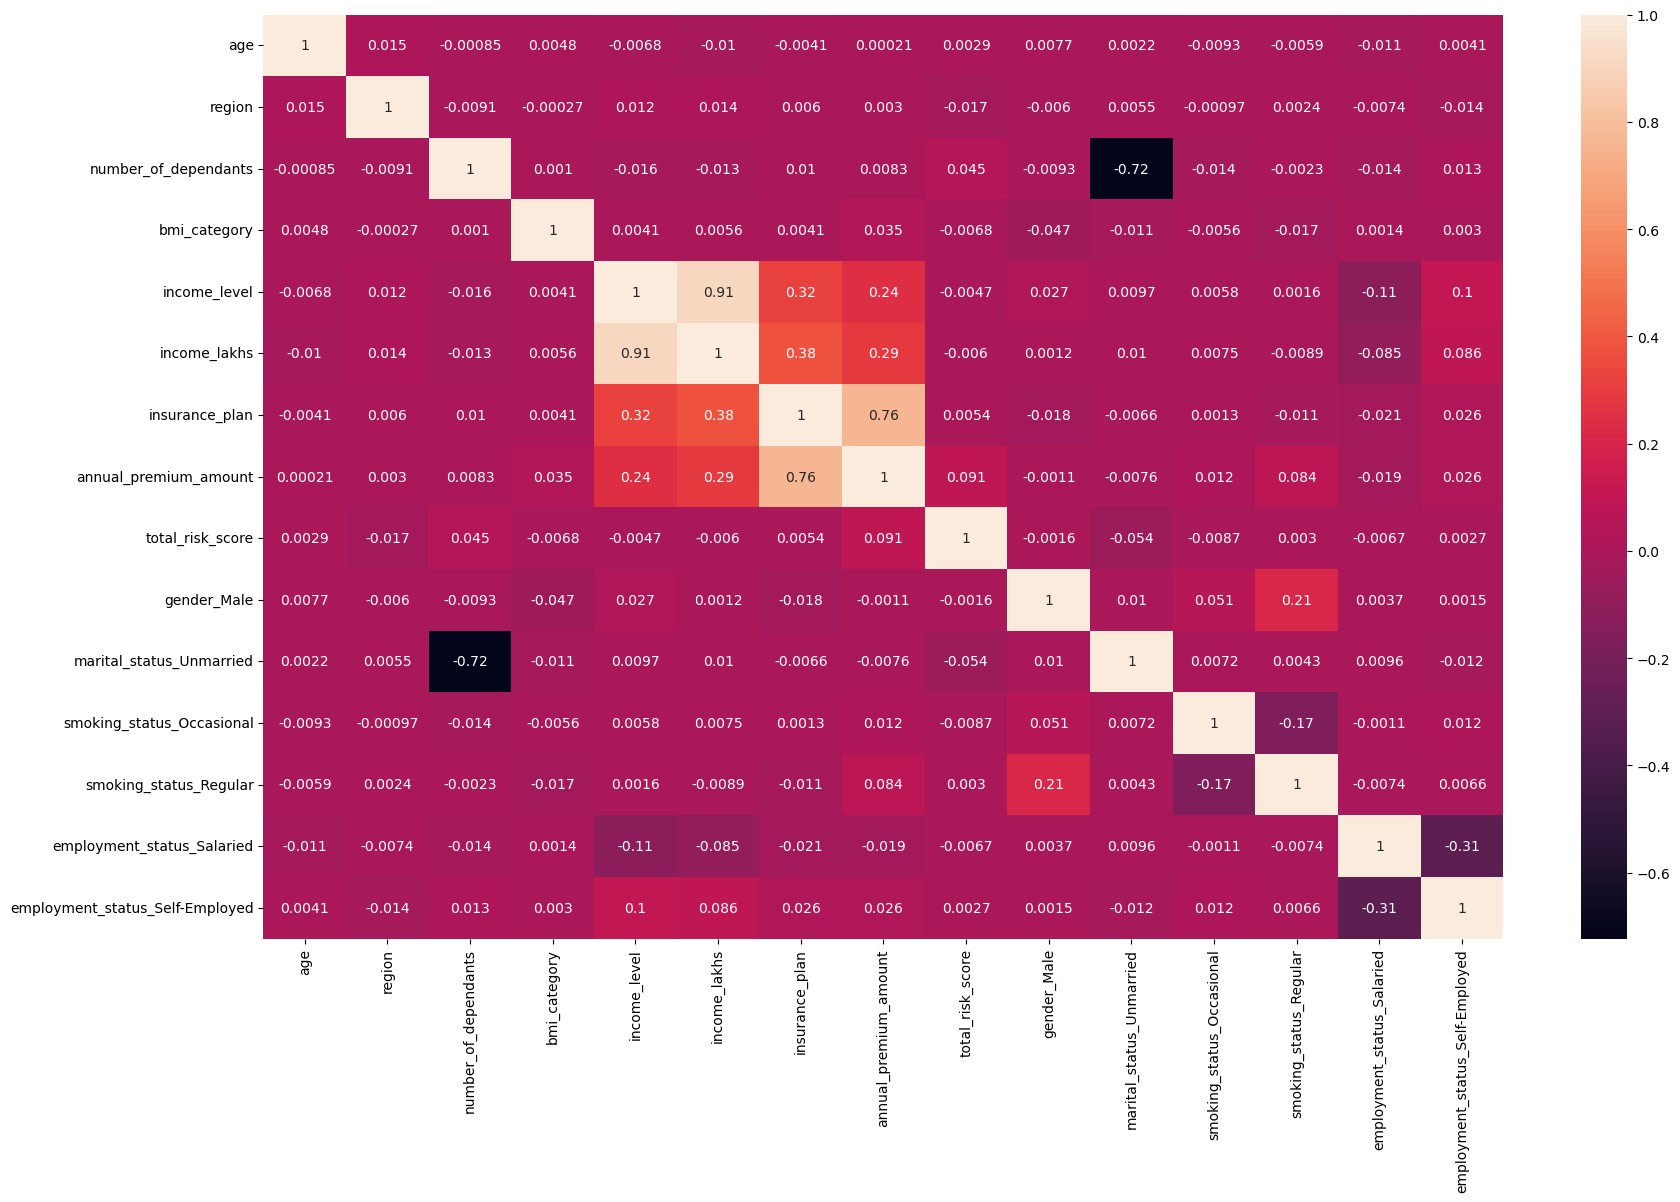

In [168]:
cm = df1.corr()

plt.figure(figsize = (20,12))
sns.heatmap(cm, annot = True)



# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

In [169]:
# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

## feature scaling

In [170]:
x = df1.drop(["income_level", "marital_status_Unmarried", "annual_premium_amount"], axis = 1)
y = df1.annual_premium_amount
x.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'insurance_plan', 'total_risk_score', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [171]:
from sklearn.model_selection import train_test_split

In [172]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [173]:
from sklearn.preprocessing import MinMaxScaler   # 0 to 1

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [174]:
x_train_scaled.shape

(14042, 12)

In [175]:
x_test_scaled.shape

(3511, 12)

# Step-3 : Apply ML models

### Linear Regression

In [176]:
from sklearn.linear_model import LinearRegression

linear_obj = LinearRegression()

linear_obj.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [177]:
lr_score = linear_obj.score(x_test_scaled, y_test)
print(lr_score)

0.5968586465738244


### model-2 : XGBoost

In [178]:
from xgboost import XGBRegressor

In [179]:
XGB_obj = XGBRegressor()

In [180]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
                'n_estimators' : [50, 60, 70, 80, 90, 100],
                'max_depth' : [3,4,5,6,7,8,9,10]
}

random_search = RandomizedSearchCV(XGB_obj, param_grid, cv = 5)

In [181]:
random_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 4, ...], 'n_estimators': [50, 60, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold t

In [182]:
random_search.best_score_

np.float64(0.598594355583191)

# CONGRATULATIONS - TARGET-1 ACHIEVED

# TARGET-2

In [183]:
y_pred = random_search.predict(x_test_scaled)
y_pred

array([9907.049 , 7043.0884, 6394.7217, ..., 6806.2485, 7000.2915,
       7067.8896], dtype=float32)

In [184]:
residuals = y_pred - y_test

residuals_pct = (residuals / y_test) * 100
residuals_pct

2028    -18.393337
9951     10.410541
9466    -28.558578
16715   -12.237316
9394     52.950599
           ...    
15902     8.942510
8317      1.951586
13576   -19.841614
1713     26.793905
3447     11.639388
Name: annual_premium_amount, Length: 3511, dtype: float64

In [185]:
result_df = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred,
    'diff' : residuals,
    'diff_pct' : residuals_pct })

result_df 

,Actual,Predicted,diff,diff_pct
2028,12140,9907.048828,-2232.951172,-18.393337
9951,6379,7043.088379,664.088379,10.410541
9466,8951,6394.721680,-2556.278320,-28.558578
16715,8995,7894.253418,-1100.746582,-12.237316
9394,4287,6556.992188,2269.992188,52.950599
...,...,...,...,...
15902,6837,7448.399414,611.399414,8.942510
8317,7455,7600.490723,145.490723,1.951586
13576,8491,6806.248535,-1684.751465,-19.841614
1713,5521,7000.291504,1479.291504,26.793905


<Axes: xlabel='diff_pct', ylabel='Count'>

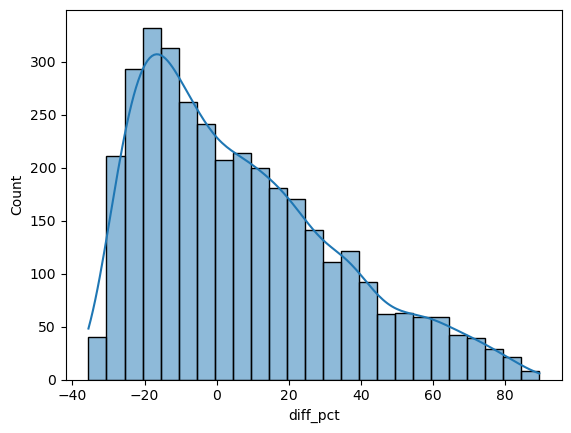

In [186]:
sns.histplot(result_df ['diff_pct'], kde = True)

In [187]:
extreme_result_df = result_df[np.abs(result_df.diff_pct) > 10]
extreme_result_df 

,Actual,Predicted,diff,diff_pct
2028,12140,9907.048828,-2232.951172,-18.393337
9951,6379,7043.088379,664.088379,10.410541
9466,8951,6394.721680,-2556.278320,-28.558578
16715,8995,7894.253418,-1100.746582,-12.237316
9394,4287,6556.992188,2269.992188,52.950599
...,...,...,...,...
14799,8055,6637.380859,-1417.619141,-17.599244
5050,7886,9893.042969,2007.042969,25.450710
13576,8491,6806.248535,-1684.751465,-19.841614
1713,5521,7000.291504,1479.291504,26.793905


### Create extreme_result_df with all the features

In [188]:
extreme_error_df = x_test.loc[extreme_result_df.index]
extreme_error_df

error_percentage = (extreme_error_df.shape[0] / x_test.shape[0]) * 100
print(error_percentage)

73.96753061805754


In [189]:
extreme_error_df.age.unique()

array([20, 22, 21, 23, 18, 24, 19])

### Finding the problem at Data level

In [190]:
df1.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'total_risk_score', 'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [191]:
# We need to find due to which feature "predicted - actual" difference is high

<Axes: xlabel='age', ylabel='Count'>

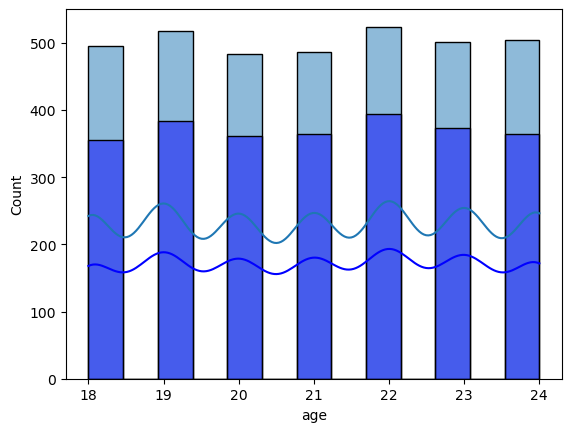

In [192]:
sns.histplot(x_test['age'], kde = True)
sns.histplot(extreme_error_df['age'], color = 'blue', kde = True)

<Axes: xlabel='region', ylabel='Count'>

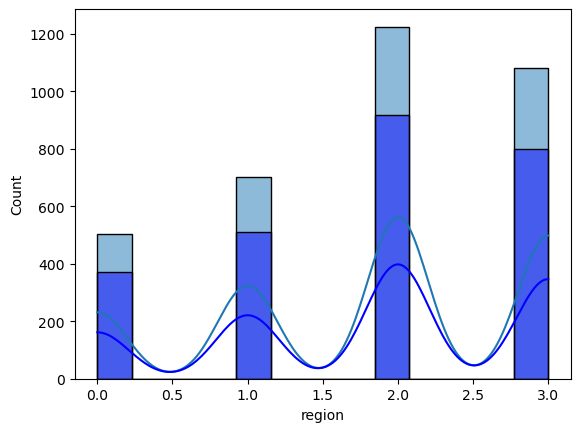

In [193]:
sns.histplot(x_test['region'], kde = True)
sns.histplot(extreme_error_df['region'], color = 'blue', kde = True)

In [194]:
x_test.shape

(3511, 12)

In [195]:
extreme_error_df.shape

(2597, 12)

In [196]:
# if the shape of error data and actual data is different for a feature
# that's means problem is occuring due to that particular feature

<Axes: xlabel='number_of_dependants', ylabel='Count'>

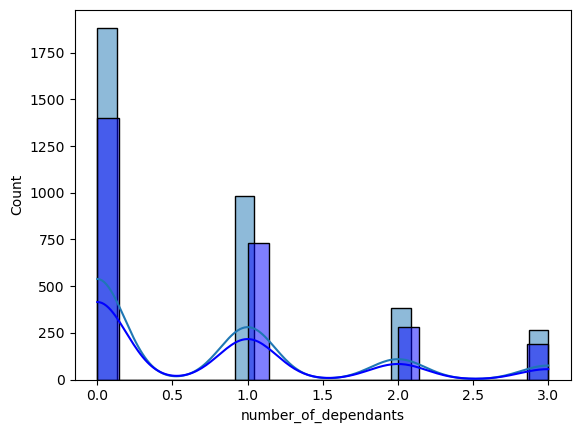

In [197]:
sns.histplot(x_test['number_of_dependants'], kde = True)
sns.histplot(extreme_error_df['number_of_dependants'], color = 'blue', kde = True)

In [198]:
type(x_test)

pandas.core.frame.DataFrame

In [199]:
x_test[x_test.age < 24]

,age,region,number_of_dependants,bmi_category,income_lakhs,insurance_plan,total_risk_score,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
2028,20,2,1,0,5,1.0,0.0,1,0,0,1,0
9951,22,3,2,0,7,0.0,0.0,1,0,1,0,0
9466,21,3,0,0,7,0.0,0.0,0,0,0,1,0
16715,23,2,1,2,31,0.0,8.0,0,0,0,0,1
9394,22,0,0,0,33,0.0,0.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
14799,22,2,1,0,6,0.0,0.0,0,0,0,0,0
5050,22,1,0,0,15,1.0,0.0,0,0,0,0,0
11972,23,1,1,0,30,0.0,12.0,1,0,0,0,0
15902,20,2,2,0,8,0.0,6.0,1,0,1,1,0


In [200]:
# People with age less then 24 are unpredicatable

# people whose age < 24, their the "predict - actual' difference is more

# Data Segmentation